In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv(r'df_final.csv')

In [4]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor

In [5]:
TARGET = "Sales"

X = df.drop(columns=[TARGET])
y = df[TARGET]


In [6]:
cat_cols = X.select_dtypes(include="object").columns
print("Categorical columns:", cat_cols)

# One-Hot Encoding
X = pd.get_dummies(
    X,
    columns=cat_cols,
    drop_first=True
)


Categorical columns: Index(['PromoInterval', 'PromoList'], dtype='object')


In [7]:
X.columns = [
    re.sub(r'[\[\]<]', '_', str(col))
    for col in X.columns
]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
#Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_r2   = r2_score(y_test, rf_pred)

print("Random Forest")
print(f"RMSE : {rf_rmse:.4f}")
print(f"MAE  : {rf_mae:.4f}")
print(f"R^2  : {rf_r2:.4f}")

In [ ]:
# 이미 학습 완료된 상태
# rf_model.fit(X_train, y_train)

y_pred = rf_model.predict(X_test)


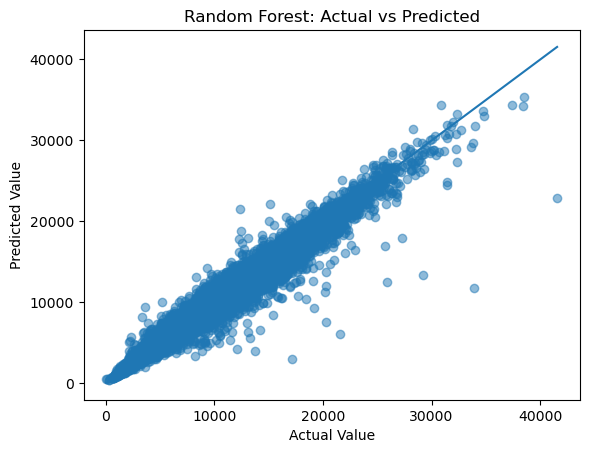

In [14]:
#실제값 vs 예측값
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel("Actual Value")
plt.ylabel("Predicted Value")
plt.title("Random Forest: Actual vs Predicted")

# 완벽 예측 기준선
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])

plt.show()

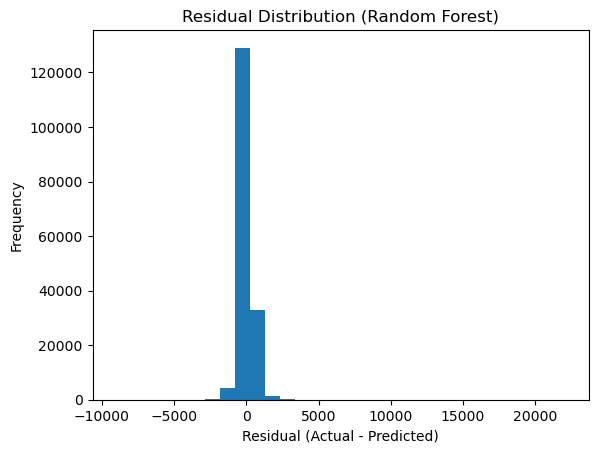

In [15]:
#잔차(Residual) 분포
residuals = y_test - y_pred

plt.figure()
plt.hist(residuals, bins=30)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution (Random Forest)")
plt.show()


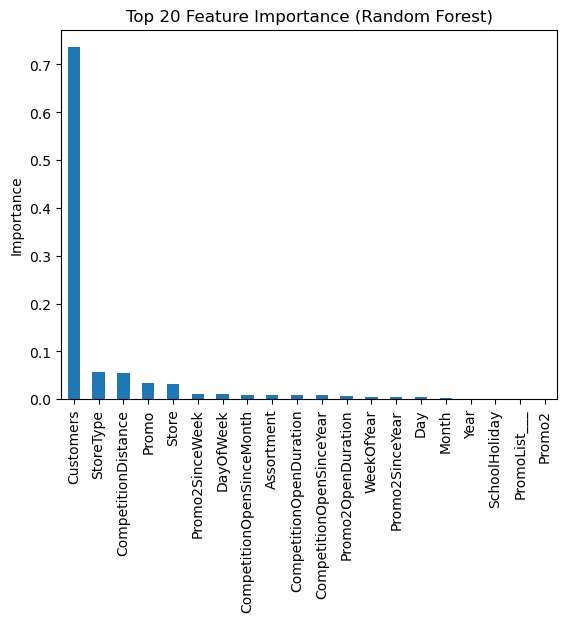

In [16]:
#피처 중요도 (Feature Importance)
import pandas as pd

importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure()
importance.head(20).plot(kind="bar")
plt.ylabel("Importance")
plt.title("Top 20 Feature Importance (Random Forest)")
plt.show()


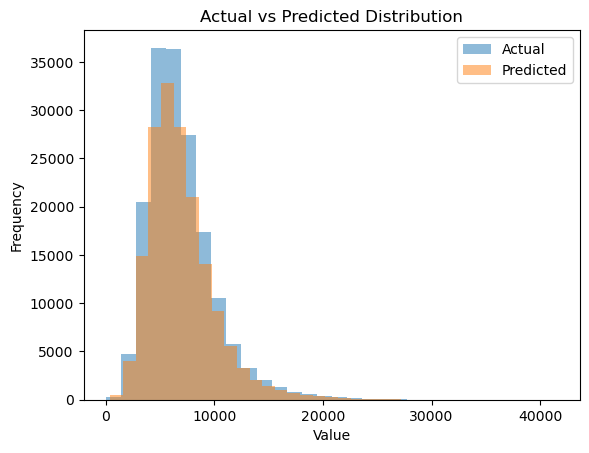

In [17]:
#예측값 분포 vs 실제값 분포
plt.figure()
plt.hist(y_test, bins=30, alpha=0.5, label="Actual")
plt.hist(y_pred, bins=30, alpha=0.5, label="Predicted")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Actual vs Predicted Distribution")
plt.legend()
plt.show()

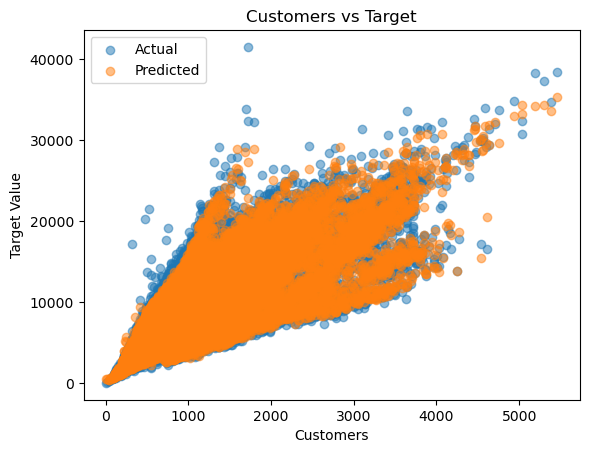

In [18]:
#중요 변수 하나로 관계 확인
top_feature = importance.index[0]

plt.figure()
plt.scatter(X_test[top_feature], y_test, alpha=0.5, label="Actual")
plt.scatter(X_test[top_feature], y_pred, alpha=0.5, label="Predicted")
plt.xlabel(top_feature)
plt.ylabel("Target Value")
plt.title(f"{top_feature} vs Target")
plt.legend()
plt.show()

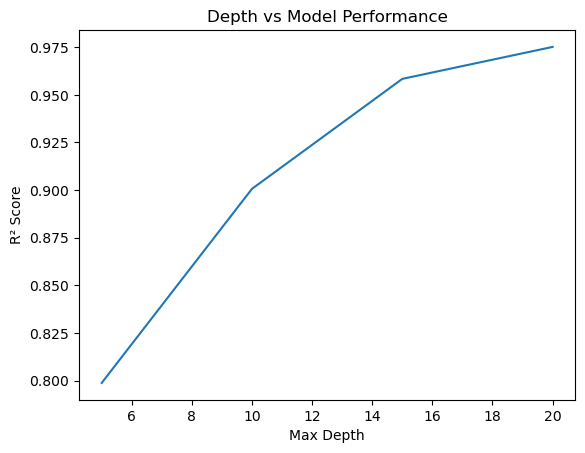

In [22]:
#트리 깊이별 성능 간접 체크
depths = [5, 10, 15, 20]
scores = []

from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

for d in depths:
    temp_model = RandomForestRegressor(
        n_estimators=100,
        max_depth=d,
        random_state=42,
        n_jobs=-1
    )
    temp_model.fit(X_train, y_train)
    pred = temp_model.predict(X_test)
    scores.append(r2_score(y_test, pred))

plt.figure()
plt.plot(depths, scores)
plt.xlabel("Max Depth")
plt.ylabel("R² Score")
plt.title("Depth vs Model Performance")
plt.show()

In [23]:
#기준 데이터 한 줄 선택
import numpy as np
import pandas as pd

# 기준 데이터: X_train 평균값
base_row = X_train.mean().to_frame().T


In [24]:
#CompetitionDistance 변화 시나리오 생성
# CompetitionDistance 범위 설정
cd_min = X_train["CompetitionDistance"].quantile(0.05)
cd_max = X_train["CompetitionDistance"].quantile(0.95)

cd_values = np.linspace(cd_min, cd_max, 50)

scenario_df = pd.concat([base_row] * len(cd_values), ignore_index=True)
scenario_df["CompetitionDistance"] = cd_values


In [25]:
#Random Forest 예측
scenario_pred = rf_model.predict(scenario_df)


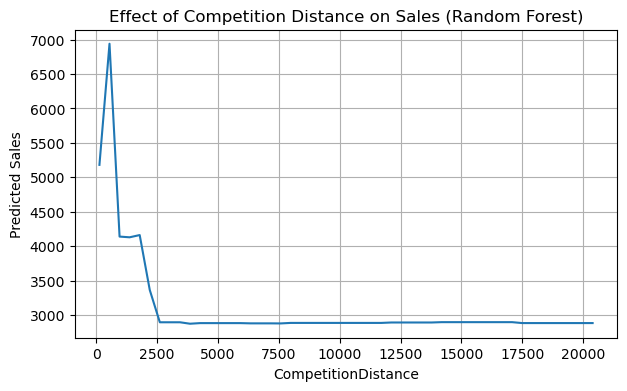

In [26]:
#결과 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(7,4))
plt.plot(cd_values, scenario_pred)
plt.xlabel("CompetitionDistance")
plt.ylabel("Predicted Sales")
plt.title("Effect of Competition Distance on Sales (Random Forest)")
plt.grid(True)
plt.show()


In [28]:
#결과를 데이터프레임으로 보기
result_df = pd.DataFrame({
    "CompetitionDistance": cd_values,
    "PredictedSales": scenario_pred
})

result_df.head()


,CompetitionDistance,PredictedSales
0,130.000000,5181.143333
1,543.469388,6939.923333
2,956.938776,4139.963333
3,1370.408163,4129.660000
4,1783.877551,4162.103333


In [30]:
#기준 데이터 생성
import pandas as pd
import numpy as np

# 평균 기준 매장 1개 생성
base_row = X_train.mean().to_frame().T

# Promo 컬럼 존재 여부 확인
assert "Promo" in base_row.columns, "Promo 컬럼이 없습니다."


In [31]:
#Promo OFF / ON 시나리오 생성
scenario_promo = pd.concat([base_row, base_row], ignore_index=True)

scenario_promo.loc[0, "Promo"] = 0  # Promo 없음
scenario_promo.loc[1, "Promo"] = 1  # Promo 있음


In [32]:
#Random Forest로 매출 예측
promo_pred = rf_model.predict(scenario_promo)

In [33]:
#결과 정리
promo_effect_df = pd.DataFrame({
    "Promo": ["No Promo", "Promo"],
    "Predicted Sales": promo_pred
})

print(promo_effect_df)
print(f"\nPromo 효과 차이: {promo_pred[1] - promo_pred[0]:.2f}")

      Promo  Predicted Sales
0  No Promo      2883.783333
1     Promo      7368.650000

Promo 효과 차이: 4484.87


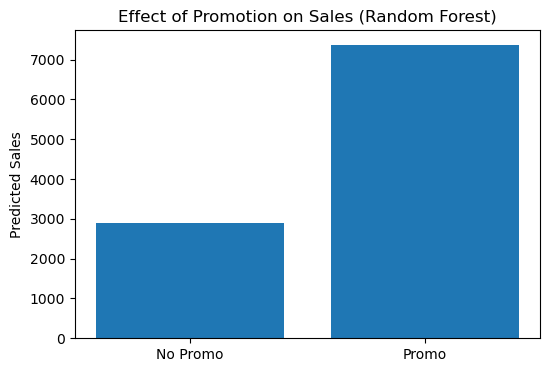

In [34]:
#시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(promo_effect_df["Promo"], promo_effect_df["Predicted Sales"])
plt.ylabel("Predicted Sales")
plt.title("Effect of Promotion on Sales (Random Forest)")
plt.show()

In [35]:
#여러 매장 기준 평균 효과 보기
# 랜덤 매장 200개 샘플링
sample_df = X_test.sample(200, random_state=42)

promo_on = sample_df.copy()
promo_off = sample_df.copy()

promo_on["Promo"] = 1
promo_off["Promo"] = 0

pred_on = rf_model.predict(promo_on)
pred_off = rf_model.predict(promo_off)

print("평균 Promo 효과:", np.mean(pred_on - pred_off))

평균 Promo 효과: 830.7146833333334


In [47]:
# 1) 원본 df에서 StoreType 관련 컬럼 찾기
print([c for c in df.columns if "store" in c.lower()])

# 2) 모델 입력 X에서 store 관련 컬럼 찾기
print([c for c in X_train.columns if "store" in c.lower()])

['Store', 'StoreType']
['Store', 'StoreType']


StoreType 종류: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
   StoreType  PredictedSales
3          3     8159.013333
0          0     2894.763333
1          1     2894.763333
2          2     2883.783333


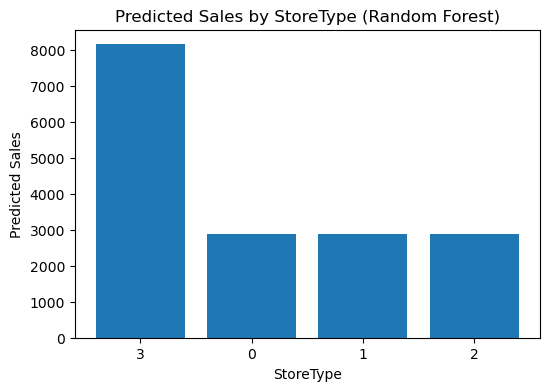

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

# 평균 매장 생성
base_row = X_train.mean().to_frame().T

# StoreType의 실제 값 확인 (보통 0~3)
store_types = sorted(X_train["StoreType"].unique())

print("StoreType 종류:", store_types)

scenario_rows = []

for st in store_types:
    row = base_row.copy()
    row["StoreType"] = st
    scenario_rows.append(row)

scenario_df = pd.concat(scenario_rows, ignore_index=True)

# 예측
pred_sales = rf_model.predict(scenario_df)

# 결과 정리
result_df = pd.DataFrame({
    "StoreType": store_types,
    "PredictedSales": pred_sales
}).sort_values("PredictedSales", ascending=False)

print(result_df)

# 시각화
plt.figure(figsize=(6,4))
plt.bar(result_df["StoreType"].astype(str), result_df["PredictedSales"])
plt.xlabel("StoreType")
plt.ylabel("Predicted Sales")
plt.title("Predicted Sales by StoreType (Random Forest)")
plt.show()


In [49]:
#promo2 컬럼 확인
print("Promo2 값 분포:")
print(X_train["Promo2"].value_counts())

Promo2 값 분포:
Promo2
0    337488
1    336233
Name: count, dtype: int64


In [50]:
#기준 매장 (평균 값) 생성
import pandas as pd
import matplotlib.pyplot as plt

base_row = X_train.mean().to_frame().T

In [52]:
#Promo2 시나리오 생성
scenario_df = pd.concat([base_row, base_row], ignore_index=True)

scenario_df.loc[0, "Promo2"] = 0  # Promo2 없음
scenario_df.loc[1, "Promo2"] = 1  # Promo2 있음

In [53]:
#Random Forest로 매출 예측
pred_sales = rf_model.predict(scenario_df)

In [54]:
#결과 정리
result_df = pd.DataFrame({
    "Promo2": ["No Promo2", "Promo2"],
    "PredictedSales": pred_sales
})

print(result_df)
print(f"\nPromo2 효과 차이: {pred_sales[1] - pred_sales[0]:.2f}")


      Promo2  PredictedSales
0  No Promo2     2883.783333
1     Promo2     2885.120000

Promo2 효과 차이: 1.34


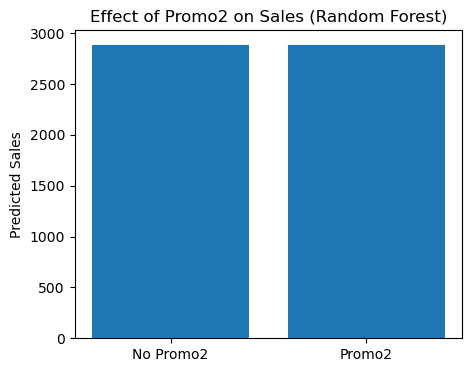

In [55]:
#시각화
plt.figure(figsize=(5,4))
plt.bar(result_df["Promo2"], result_df["PredictedSales"])
plt.ylabel("Predicted Sales")
plt.title("Effect of Promo2 on Sales (Random Forest)")
plt.show()

### 여기는 promo2 기간을 늘렸을 때의 경우.

In [56]:
print([c for c in X_train.columns if "promo2" in c.lower()])

['Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'Promo2OpenDuration']


In [59]:
import pandas as pd
import matplotlib.pyplot as plt

base_row = X_train.mean().to_frame().T

# Promo2는 켜둔 상태로 분석
base_row["Promo2"] = 1


In [60]:
current_year = 2015  # 데이터 기준 연도

promo_scenarios = [
    {"label": "Short (1 year)", "year": current_year - 1},
    {"label": "Medium (3 years)", "year": current_year - 3},
    {"label": "Long (5 years)", "year": current_year - 5},
]

scenario_rows = []

for s in promo_scenarios:
    row = base_row.copy()
    row["Promo2SinceYear"] = s["year"]
    row["Promo2SinceWeek"] = 1  # 연초부터 시작했다고 가정
    scenario_rows.append(row)

scenario_df = pd.concat(scenario_rows, ignore_index=True)


In [61]:
pred_sales = rf_model.predict(scenario_df)


In [62]:
result_df = pd.DataFrame({
    "Promo2_Duration": [s["label"] for s in promo_scenarios],
    "PredictedSales": pred_sales
})

print(result_df)


    Promo2_Duration  PredictedSales
0    Short (1 year)     2890.416667
1  Medium (3 years)     2890.416667
2    Long (5 years)     2890.416667


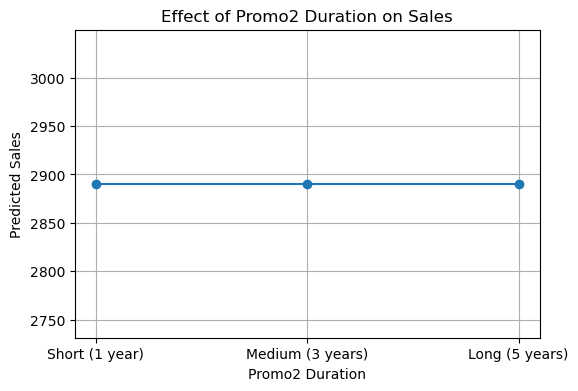

In [63]:
plt.figure(figsize=(6,4))
plt.plot(result_df["Promo2_Duration"], result_df["PredictedSales"], marker="o")
plt.xlabel("Promo2 Duration")
plt.ylabel("Predicted Sales")
plt.title("Effect of Promo2 Duration on Sales")
plt.grid(True)
plt.show()


### “Random Forest 기반 시뮬레이션 결과, Promo2의 도입 여부는 매출에 영향을 주지만, 프로모션 지속 기간(1~5년)에 따른 추가적인 매출 증가는 관찰되지 않았다. 이는 장기 프로모션 효과가 일정 수준 이후 안정화되는 패턴으로 해석할 수 있다.”

In [64]:
#컬럼 존재 확인
[c for c in X_train.columns if "competition" in c.lower()]

['CompetitionDistance',
 'CompetitionOpenSinceMonth',
 'CompetitionOpenSinceYear',
 'CompetitionOpenDuration']

In [65]:
#기준 매장(평균 조건) 생성
import pandas as pd
import matplotlib.pyplot as plt

base_row = X_train.mean().to_frame().T

In [66]:
#CompetitionOpenDuration 시나리오 생성
duration_values = [0, 6, 12, 24, 48]  # 단위: months (데이터 기준에 맞게)

scenario_rows = []

for d in duration_values:
    row = base_row.copy()
    row["CompetitionOpenDuration"] = d
    scenario_rows.append(row)

scenario_df = pd.concat(scenario_rows, ignore_index=True)

In [67]:
#매출 예측
pred_sales = rf_model.predict(scenario_df)

In [68]:
#결과 정리
result_df = pd.DataFrame({
    "CompetitionOpenDuration": duration_values,
    "PredictedSales": pred_sales
})

print(result_df)

   CompetitionOpenDuration  PredictedSales
0                        0         2893.31
1                        6         2893.31
2                       12         2893.31
3                       24         2893.90
4                       48         2893.90


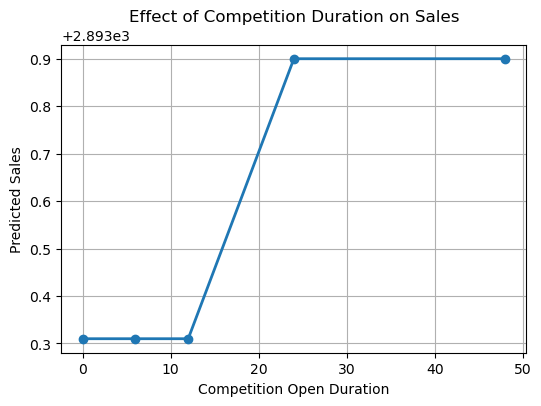

In [69]:
#시각화
plt.figure(figsize=(6,4))
plt.plot(
    result_df["CompetitionOpenDuration"],
    result_df["PredictedSales"],
    marker="o",
    linewidth=2
)
plt.xlabel("Competition Open Duration")
plt.ylabel("Predicted Sales")
plt.title("Effect of Competition Duration on Sales")
plt.grid(True)
plt.show()

In [70]:
#Feature Importance
fi = pd.Series(
    rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

fi.head(15)


Customers                    0.736121
StoreType                    0.057394
CompetitionDistance          0.054285
Promo                        0.034123
Store                        0.032212
Promo2SinceWeek              0.010810
DayOfWeek                    0.010062
CompetitionOpenSinceMonth    0.009225
Assortment                   0.008834
CompetitionOpenDuration      0.008286
CompetitionOpenSinceYear     0.007936
Promo2OpenDuration           0.006916
WeekOfYear                   0.004700
Promo2SinceYear              0.004641
Day                          0.004465
dtype: float64

In [ ]:
X_train[["StoreType", "Assortment"]].drop_duplicates().sort_values(
    ["StoreType", "Assortment"]
)